# 03 RAGAS Answer Evaluation

Simple notebook-only answer evaluation. It loads the RAGAS-generated testset, uses the method selected by notebook 02, generates or loads answers, and runs RAGAS answer metrics.

In [1]:

from pathlib import Path
import json
import math
import os
import sys
from collections import defaultdict

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from rank_bm25 import BM25Okapi
from ragas import evaluate
from sklearn.feature_extraction.text import TfidfVectorizer

from src.data.chunking import chunk_documents
from src.data.clean_text import normalize_for_match, tokenize_vi
from src.data.load_dataset import load_documents_from_jsonl
from src.data.schema import SearchResult

CORPUS_PATH = PROJECT_ROOT / "data/processed/labor_corpus.jsonl"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RAGAS_TESTSET_JSON = REPORTS_DIR / "ragas_testset.json"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RETRIEVAL_MD = REPORTS_DIR / "retrieval_evaluation.md"
RAG_ANSWERS_JSON = REPORTS_DIR / "rag_answers.json"
RAGAS_EVAL_JSON = REPORTS_DIR / "ragas_evaluation.json"
RAGAS_EVAL_MD = REPORTS_DIR / "ragas_evaluation.md"

DEFAULT_MODEL = "gemini-3.1-flash-lite"
DEFAULT_EMBEDDING_MODEL = "models/gemini-embedding-001"
TOP_K = 5
BENCHMARK_MAX_CHUNKS = 3500
METHODS = ["bm25", "vector", "hybrid", "hybrid_rrf", "hybrid_rrf_mmr"]

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def gemini_keys():
    load_dotenv(PROJECT_ROOT / ".env")
    raw_values = [
        os.getenv("GOOGLE_API_KEY") or "",
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ]
    keys, seen = [], set()
    for raw_value in raw_values:
        for key in raw_value.split(","):
            key = key.strip()
            if key and key not in seen:
                keys.append(key)
                seen.add(key)
    return keys


def load_ragas_testset():
    if not RAGAS_TESTSET_JSON.exists():
        raise FileNotFoundError("Missing reports/ragas_testset.json. Run the RAGAS TestsetGenerator cell first.")
    payload = json.loads(RAGAS_TESTSET_JSON.read_text(encoding="utf-8"))
    if not payload.get("generated_with_ragas"):
        raise ValueError("reports/ragas_testset.json must come from RAGAS TestsetGenerator.")
    items = payload.get("items") or []
    if len(items) < 30:
        raise ValueError("RAGAS testset must contain at least 30 accepted questions.")
    return payload, items



def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value

from ragas.run_config import RunConfig
from src.generation.gemini_client import BatchGeminiClient
from src.generation.prompt import build_rag_prompt

C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Testset and Selected Retriever

In [2]:

testset_meta, testset = load_ragas_testset()
retrieval_report = json.loads(RETRIEVAL_JSON.read_text(encoding="utf-8"))
selected_method = retrieval_report["selected_method"]
pd.DataFrame([{k: testset_meta.get(k) for k in ["generated_with_ragas", "candidate_target", "accepted_count"]}])


,generated_with_ragas,candidate_target,accepted_count
0,True,40,30


In [3]:
pd.DataFrame(testset)[["id", "topic", "source", "question", "reference"]].head(10)

,id,topic,source,question,reference
0,ragas_001,single_hop_specific_query_synthesizer,ragas_testset_generator,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...,"Khi giải thể, xí nghiệp phải thực hiện các ngh..."
1,ragas_002,single_hop_specific_query_synthesizer,ragas_testset_generator,Quy trình giải thể Xí nghiệp liên doanh được q...,Khi Xí nghiệp liên doanh hoạt động sản xuất ki...
2,ragas_003,single_hop_specific_query_synthesizer,ragas_testset_generator,Khi nào thì hội đồng quản trị của xí nghiệp li...,"Theo quy định, Hội đồng quản trị Xí nghiệp liê..."
3,ragas_004,single_hop_specific_query_synthesizer,ragas_testset_generator,CHƯƠNG VI nói về cái gì vậy ạ?,CHƯƠNG VI quy định về ĐIỀU KHOẢN THI HÀNH.
4,ragas_005,single_hop_specific_query_synthesizer,ragas_testset_generator,anh oi cho hoi cai Nghị định số 103/1999/NĐ-CP...,"Theo quy định tại Nghị định số 103/1999/NĐ-CP,..."
5,ragas_006,single_hop_specific_query_synthesizer,ragas_testset_generator,Theo Nghị định số 103/1999/NĐ-CP của Chính phủ...,"Các văn bản do người được giao, người mua, ngư..."
6,ragas_007,single_hop_specific_query_synthesizer,ragas_testset_generator,Nghị định số 103/1999/NĐ-CP quy định gì về việ...,"Theo Nghị định số 103/1999/NĐ-CP, người được g..."
7,ragas_008,single_hop_specific_query_synthesizer,ragas_testset_generator,Khi các bên lập phương án dựa trên hướng phát ...,"Theo Nghị định số 103/1999/NĐ-CP, khi người đư..."
8,ragas_009,single_hop_specific_query_synthesizer,ragas_testset_generator,UBND TỈNH LÂM ĐỒNG đã đánh giá như thế nào về ...,"Theo chỉ thị của UBND TỈNH LÂM ĐỒNG, mặc dù ho..."
9,ragas_010,single_hop_specific_query_synthesizer,ragas_testset_generator,"Theo chỉ thị của UBND tỉnh Lâm Đồng, tình hình...","Theo chỉ thị của UBND tỉnh Lâm Đồng, công tác ..."


## 2. Generate or Load Answers

In [4]:

def chunk_text(chunk):
    return f"{chunk.title} {chunk.text}"


def normalize_rows(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
    return np.asarray(matrix / norms, dtype="float32")


class NotebookRetriever:
    def __init__(self, chunks):
        self.chunks = chunks
        self.bm25 = BM25Okapi([tokenize_vi(chunk_text(chunk)) for chunk in chunks])
        self.vectorizer = TfidfVectorizer(max_features=384, ngram_range=(1, 2))
        self.embeddings = normalize_rows(self.vectorizer.fit_transform([chunk_text(chunk) for chunk in chunks]).toarray())
        self.index = faiss.IndexFlatIP(self.embeddings.shape[1])
        self.index.add(self.embeddings)

    def retrieve(self, query, method, top_k=TOP_K):
        sparse = self.retrieve_bm25(query, max(30, top_k * 5))
        vector = self.retrieve_vector(query, max(30, top_k * 5))
        if method == "bm25":
            return sparse[:top_k]
        if method == "vector":
            return vector[:top_k]
        if method == "hybrid":
            return self.weighted_hybrid(sparse, vector, top_k)
        if method == "hybrid_rrf":
            return self.rrf([sparse, vector], top_k)
        if method == "hybrid_rrf_mmr":
            return self.mmr(self.rrf([sparse, vector], max(20, top_k * 4)), top_k)
        raise ValueError(method)

    def retrieve_bm25(self, query, top_k):
        scores = self.bm25.get_scores(tokenize_vi(query))
        indices = sorted(range(len(scores)), key=lambda idx: scores[idx], reverse=True)[:top_k]
        return [SearchResult(self.chunks[idx], float(scores[idx]), "bm25", rank) for rank, idx in enumerate(indices, start=1)]

    def retrieve_vector(self, query, top_k):
        query_vector = normalize_rows(self.vectorizer.transform([query]).toarray())
        scores, indices = self.index.search(query_vector, top_k)
        return [
            SearchResult(self.chunks[int(idx)], float(score), "vector", rank)
            for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1)
            if idx >= 0
        ]

    @staticmethod
    def minmax(results):
        if not results:
            return {}
        scores = [result.score for result in results]
        low, high = min(scores), max(scores)
        if high == low:
            return {result.chunk.chunk_id: 1.0 for result in results}
        return {result.chunk.chunk_id: (result.score - low) / (high - low) for result in results}

    def weighted_hybrid(self, sparse, vector, top_k):
        sparse_scores = self.minmax(sparse)
        vector_scores = self.minmax(vector)
        chunks = {result.chunk.chunk_id: result.chunk for result in sparse + vector}
        scores = defaultdict(float)
        for chunk_id, score in sparse_scores.items():
            scores[chunk_id] += 0.55 * score
        for chunk_id, score in vector_scores.items():
            scores[chunk_id] += 0.45 * score
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def rrf(result_lists, top_k):
        scores, chunks = defaultdict(float), {}
        for results in result_lists:
            for rank, result in enumerate(results, start=1):
                chunks[result.chunk.chunk_id] = result.chunk
                scores[result.chunk.chunk_id] += 1.0 / (60 + rank)
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid_rrf", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def mmr(results, top_k):
        selected, seen_docs = [], set()
        for result in results:
            if result.chunk.doc_id in seen_docs and len(selected) < max(1, top_k - 1):
                continue
            selected.append(result)
            seen_docs.add(result.chunk.doc_id)
            if len(selected) == top_k:
                break
        if len(selected) < top_k:
            selected.extend(result for result in results if result not in selected)
        return [SearchResult(result.chunk, result.score, "hybrid_rrf_mmr", rank) for rank, result in enumerate(selected[:top_k], start=1)]


In [5]:

def load_cached_answers():
    if not RAG_ANSWERS_JSON.exists():
        return []
    return json.loads(RAG_ANSWERS_JSON.read_text(encoding="utf-8"))


def generate_answers():
    cached = load_cached_answers()
    if cached and len(cached) >= len(testset) and all(row.get("retrieval_method") == selected_method for row in cached):
        return cached[: len(testset)], True, "cached_answers"
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when cached answers are missing.")
    chunks = chunk_documents(load_documents_from_jsonl(str(CORPUS_PATH)))[:BENCHMARK_MAX_CHUNKS]
    retriever = NotebookRetriever(chunks)
    client = BatchGeminiClient(api_keys=keys, model=DEFAULT_MODEL)
    answers = []
    for item in testset:
        results = retriever.retrieve(item["question"], selected_method, TOP_K)
        prompt, citations = build_rag_prompt(item["question"], results)
        answers.append({
            "id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "answer": client.generate(prompt),
            "contexts": [result.chunk.text for result in results],
            "citations": citations,
            "retrieval_method": selected_method,
            "answer_backend": "gemini",
        })
    RAG_ANSWERS_JSON.write_text(json.dumps(answers, ensure_ascii=False, indent=2), encoding="utf-8")
    return answers, False, "generated"


answers, answers_cached, cache_reason = generate_answers()
print("answers:", len(answers))
print("retrieval method:", selected_method)
print("answers cached:", answers_cached)


answers: 30
retrieval method: hybrid
answers cached: True


## 3. RAGAS Metrics

In [6]:

def load_cached_metrics():
    if not RAGAS_EVAL_JSON.exists():
        return {}, []
    payload = json.loads(RAGAS_EVAL_JSON.read_text(encoding="utf-8"))
    return payload.get("aggregate") or {}, payload.get("details") or []


def build_llm_and_embeddings():
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when cached RAGAS metrics are missing.")
    os.environ.setdefault("GOOGLE_API_KEY", keys[0])
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
    return (
        ChatGoogleGenerativeAI(model=DEFAULT_MODEL, google_api_key=keys[0], temperature=0),
        GoogleGenerativeAIEmbeddings(model=DEFAULT_EMBEDDING_MODEL, google_api_key=keys[0]),
    )


def answer_metrics():
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        from ragas.metrics import answer_correctness, answer_relevancy, context_precision, context_recall, faithfulness
    answer_relevancy.strictness = 1
    return [context_precision, context_recall, faithfulness, answer_relevancy, answer_correctness]


desired_metrics = ["context_precision", "context_recall", "faithfulness", "answer_relevancy", "answer_correctness"]
cached_aggregate, cached_details = load_cached_metrics()
if cached_aggregate and all(metric in cached_aggregate for metric in desired_metrics) and len(cached_details) == len(answers):
    aggregate, details, metrics_cached = cached_aggregate, cached_details, True
else:
    dataset = Dataset.from_list([
        {"user_input": row["question"], "response": row["answer"], "retrieved_contexts": row["contexts"], "reference": row["reference"]}
        for row in answers
    ])
    frame = pd.DataFrame(cached_details) if len(cached_details) == len(answers) else pd.DataFrame(dataset)
    llm, embeddings = build_llm_and_embeddings()
    run_config = RunConfig(timeout=120, max_retries=1, max_wait=5, max_workers=1)
    for metric in [metric for metric in answer_metrics() if metric.name not in frame or not frame[metric.name].notna().any()]:
        result = evaluate(dataset=dataset, metrics=[metric], llm=llm, embeddings=embeddings, run_config=run_config, show_progress=False)
        frame[metric.name] = result.to_pandas()[metric.name].reset_index(drop=True)
    aggregate = {metric: float(frame[metric].mean()) for metric in desired_metrics if metric in frame and pd.notna(frame[metric].mean())}
    details = frame.astype(object).where(pd.notna(frame), None).to_dict("records")
    metrics_cached = False

ragas_report = {
    "backend": "ragas_evaluate",
    "model": DEFAULT_MODEL,
    "cached": answers_cached or metrics_cached,
    "answers_cached": answers_cached,
    "metrics_cached": metrics_cached,
    "cache_reason": cache_reason if answers_cached else "cached_metrics" if metrics_cached else "",
    "answer_count": len(answers),
    "retrieval_method": selected_method,
    "aggregate": aggregate,
    "details": details,
}
RAGAS_EVAL_JSON.write_text(json.dumps(sanitize(ragas_report), ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame([aggregate])


,context_precision,context_recall,faithfulness,answer_relevancy,answer_correctness
0,0.527778,0.772727,0.875935,0.760371,0.639979


### ragas_answer_metrics.png

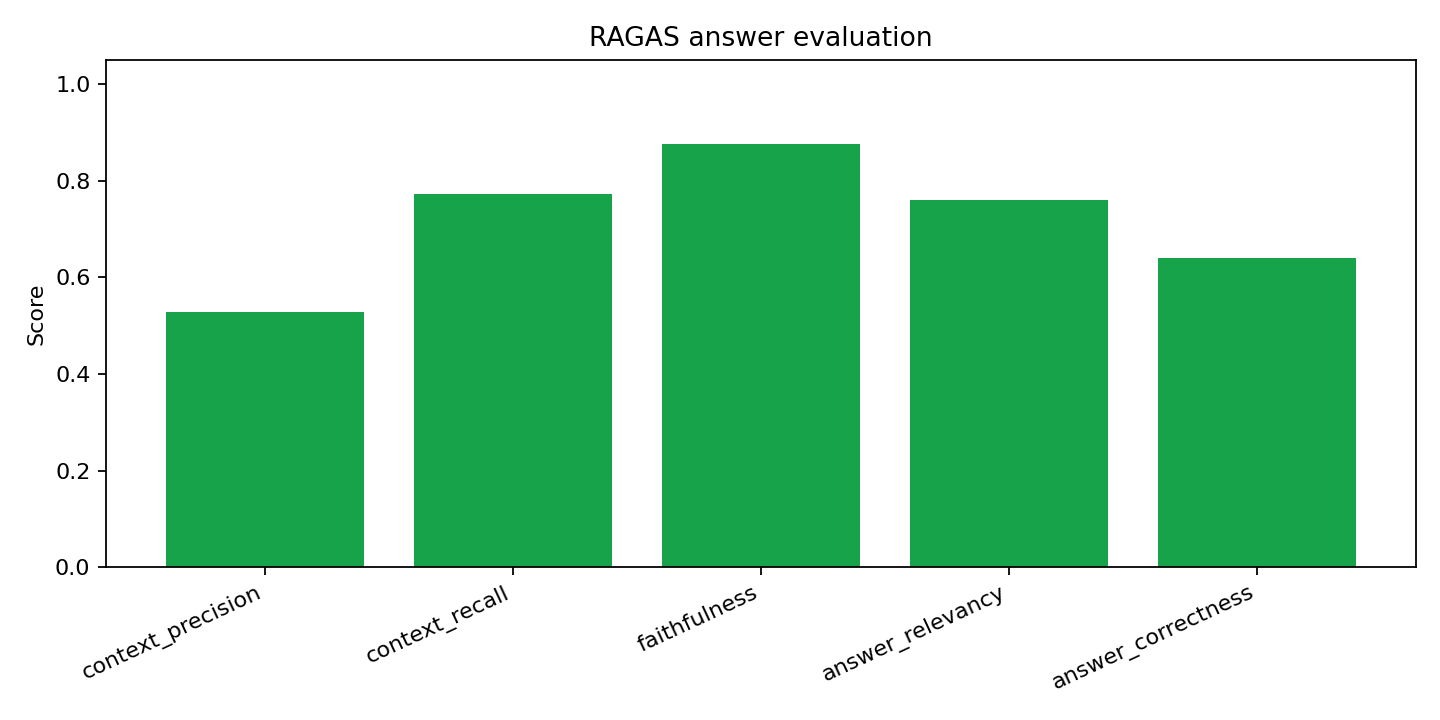

### ragas_per_question_heatmap.png

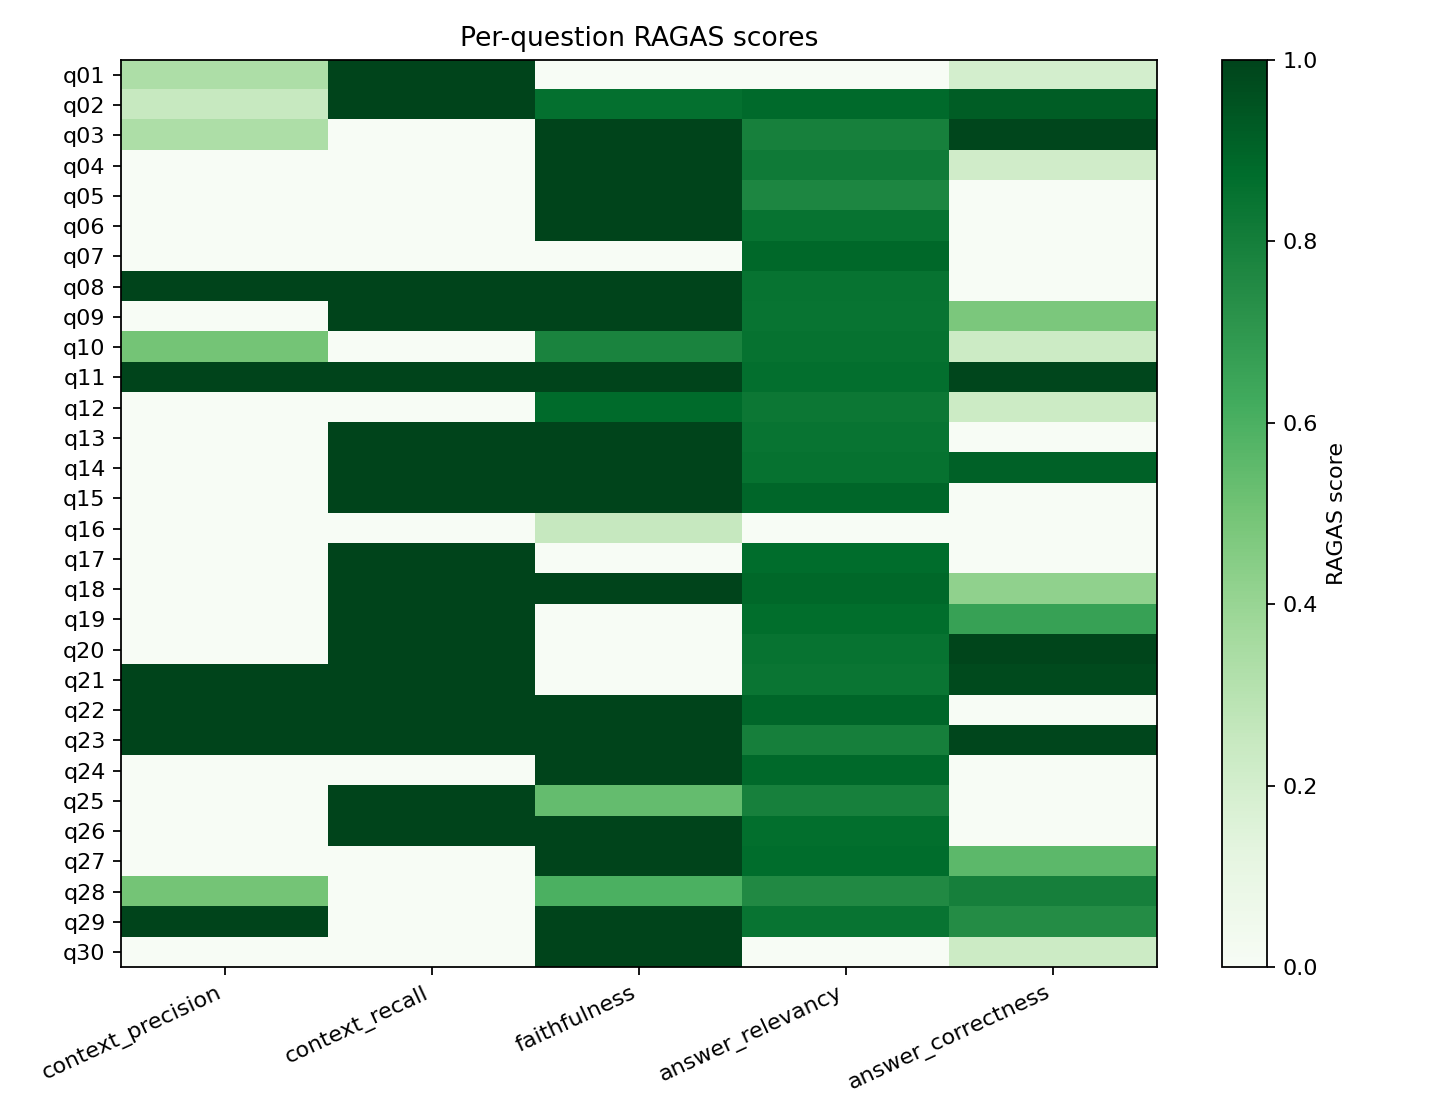

In [7]:

metrics = list(aggregate)
plt.figure(figsize=(9, 4.5))
plt.bar(metrics, [aggregate[metric] for metric in metrics], color="#16a34a")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("RAGAS answer evaluation")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ragas_answer_metrics.png", dpi=160)
plt.close()

details_df = pd.DataFrame(details)
metric_cols = [metric for metric in metrics if metric in details_df]
plt.figure(figsize=(9, 7))
plt.imshow(details_df[metric_cols].fillna(0).values, aspect="auto", cmap="Greens", vmin=0, vmax=1)
plt.colorbar(label="RAGAS score")
plt.xticks(range(len(metric_cols)), metric_cols, rotation=25, ha="right")
plt.yticks(range(len(details_df)), [f"q{idx + 1:02d}" for idx in range(len(details_df))])
plt.title("Per-question RAGAS scores")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ragas_per_question_heatmap.png", dpi=160)
plt.close()

for name in ["ragas_answer_metrics.png", "ragas_per_question_heatmap.png"]:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(FIGURES_DIR / name)))


In [8]:

lines = [
    "# RAGAS Answer Evaluation",
    "",
    f"- Backend: `{ragas_report['backend']}`",
    f"- Cached artifact used: `{ragas_report.get('cached', False)}`",
    f"- Cache reason: `{ragas_report.get('cache_reason') or 'n/a'}`",
    f"- Answers: `{ragas_report['answer_count']}`",
    f"- Retrieval method: `{ragas_report['retrieval_method']}`",
    f"- Model: `{ragas_report['model']}`",
    "",
    "| Metric | Score |",
    "|---|---:|",
]
for metric, value in aggregate.items():
    lines.append(f"| {metric} | {value:.3f} |")
lines.extend(["", "## Figures", "", "- `reports/figures/ragas_answer_metrics.png`", "- `reports/figures/ragas_per_question_heatmap.png`", "", "## Weakest Cases", ""])
details_df["mean_score"] = details_df[metric_cols].mean(axis=1)
for _, row in details_df.sort_values("mean_score").head(5).iterrows():
    question = row.get("user_input") or row.get("question") or ""
    lines.append(f"- {question} - mean={row['mean_score']:.3f}")
RAGAS_EVAL_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
details_df.sort_values("mean_score").head(8)


,user_input,retrieved_contexts,response,reference,context_precision,context_recall,faithfulness,answer_relevancy,answer_correctness,mean_score
15,Văn bản này hướng dẫn thực hiện các quy định v...,[của nhân dân lao động. Vì vậy Bộ Lao động đề ...,"Dựa trên các tài liệu được cung cấp, thông tin...",Văn bản này hướng dẫn thực hiện các quy định v...,0.000000,0.0,0.250000,0.000000,NaN,0.062500
29,Cho em hoi la cai Sở Lao động liên khu no co n...,[hợp phạm lỗi nặng sẽ bị truy tố trước toà án....,"Dựa trên các tài liệu được cung cấp, hiện tại ...","Theo quy định, Sở Lao động liên khu có nhiệm v...",0.000000,0.0,1.000000,0.000000,0.227915,0.245583
0,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...,[THÔNG TƯ Hướng dẫn thi hành quy chế lao động ...,"Hiện tại, văn bản bạn cung cấp không chứa nội ...","Khi giải thể, xí nghiệp phải thực hiện các ngh...",0.333333,1.0,0.000000,0.000000,0.195768,0.305820
11,"Theo chỉ thị của UBNND TỈNH LÂM ĐỒNG, tình hìn...",[vực này phải qua đào tạo. Quản lý chặt chẽ vi...,"Dựa trên các tài liệu được cung cấp, hiện chưa...","Theo chỉ thị của UBND tỉnh Lâm Đồng, công tác ...",0.000000,0.0,0.875000,0.831783,0.228055,0.386968
3,CHƯƠNG VI nói về cái gì vậy ạ?,[Điều 6. - Các điều kiện bảo vệ sức làm việc ấ...,"Theo nội dung được cung cấp, Chương VI quy địn...",CHƯƠNG VI quy định về ĐIỀU KHOẢN THI HÀNH.,0.000000,0.0,1.000000,0.816909,0.211162,0.405614
9,"Theo chỉ thị của UBND tỉnh Lâm Đồng, tình hình...",[QUYẾT ĐỊNH CỦA UBND TỈNH LÂM ĐỒNG Về việc ban...,"Dựa trên các tài liệu được cung cấp, các văn b...","Theo chỉ thị của UBND tỉnh Lâm Đồng, công tác ...",0.500000,0.0,0.777778,0.849952,0.230271,0.471600
27,Cty em phai chi bao nhieu % quy luong cho LD-T...,[rà soát lại việc đăng ký tổ chức dạy nghề và ...,"Dựa trên các văn bản được cung cấp, dưới đây l...","Theo quy định, các doanh nghiệp trên địa bàn t...",0.500000,NaN,0.600000,0.755343,0.794383,0.662431
24,Cho em hoi la UBNN tinh co trach nhiem gi tron...,[rà soát lại việc đăng ký tổ chức dạy nghề và ...,"Theo các tài liệu được cung cấp, trách nhiệm c...","Theo quy định, UBND tỉnh có trách nhiệm phối h...",NaN,1.0,0.538462,0.790152,NaN,0.776205
